In [1]:
#
# FINO1 data
#
import datetime
import os
from glob import glob
from os.path import join

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import plotly
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
from  plotly.graph_objs import *
import plotly.io as pio
pio.renderers.default = 'iframe'

print(os.environ["CONDA_DEFAULT_ENV"])  # Check the name of the current Conda environment

/glade/work/dettling/conda-envs/plotlyenv


In [2]:
finoRaw= pd.read_csv('/glade/campaign/ral/wsap/oracleMLSL/data/fino/raw/combined_2010_fino_data_30min.csv')

In [3]:
finoRaw['Time']= pd.to_datetime(finoRaw['Time'] )
finoRaw.index = finoRaw['Time'] 


In [4]:
print(finoRaw.index)

DatetimeIndex(['2010-01-01 00:00:00', '2010-01-01 00:30:00',
               '2010-01-01 01:00:00', '2010-01-01 01:30:00',
               '2010-01-01 02:00:00', '2010-01-01 02:30:00',
               '2010-01-01 03:00:00', '2010-01-01 03:30:00',
               '2010-01-01 04:00:00', '2010-01-01 04:30:00',
               ...
               '2010-12-31 19:30:00', '2010-12-31 20:00:00',
               '2010-12-31 20:30:00', '2010-12-31 21:00:00',
               '2010-12-31 21:30:00', '2010-12-31 22:00:00',
               '2010-12-31 22:30:00', '2010-12-31 23:00:00',
               '2010-12-31 23:30:00', '2011-01-01 00:00:00'],
              dtype='datetime64[ns]', name='Time', length=17521, freq=None)


In [5]:
for i in finoRaw.columns:
    print(i)


Time
Value_wave_dir_linear_interp:Buoy:degree
Value_wave_dir_nearest_interp:Buoy:degree
Value_wave_period_Mean:Buoy:s
Value_wave_height:Buoy:m
Correction Flux:40_m:w'q'
ustar:40_m:u'w'
u_w:40_m:m2_s-2
u_w:60_m:m2_s-2
u_w:80_m:m2_s-2
v_w:40_m:m2_s-2
v_w:60_m:m2_s-2
v_w:80_m:m2_s-2
Sensible Heat Flux:40_m:K_m_s-1
Sensible Heat Flux:60_m:K_m_s-1
Sensible Heat Flux:80_m:K_m_s-1
WindSpeed:40_m:s^-1
WindSpeed:60_m:s^-1
WindSpeed:80_m:s^-1
WindDir:40_m:degree
WindDir:60_m:degree
WindDir:80_m:degree
Pressure:30_m:Pa
Pressure:40_m:Pa
Pressure:50_m:Pa
Pressure:60_m:Pa
Pressure:70_m:Pa
Pressure:80_m:Pa
hygro_mean:30_m:%
hygro_mean:50_m:%
hygro_mean:90_m:%
pyrano_mean:30_m:w/m^2
pyrano_mean:90_m:w/m^2
Temp:30_m:C
Temp:40_m:C
Temp:50_m:C
Temp:70_m:C
Temp:100_m:C
Value_Air_Pressure:20_m:mbar
Value_Air_Pressure:90_m:mbar
Value_Surface_Temperature:Buoy_m:C
Value_Wind_Speed:40_m:m/s
Value_Wind_Speed:60_m:m/s
Value_Wind_Speed:80_m:m/s


In [6]:
finoRaw['ustar40']= ((finoRaw['u_w:40_m:m2_s-2'])**2 +  (finoRaw['v_w:40_m:m2_s-2'])**2 )**(.25)
finoRaw['ustar60'] = ((finoRaw['u_w:60_m:m2_s-2'])**2 +  (finoRaw['v_w:60_m:m2_s-2'])**2 )**(.25)
finoRaw['ustar80'] = ((finoRaw['u_w:80_m:m2_s-2'])**2 +  (finoRaw['v_w:80_m:m2_s-2'])**2 )**(.25)


In [7]:
finoRaw['Temp:60_m:C'] = (finoRaw['Temp:50_m:C'] + finoRaw['Temp:70_m:C'] )/2
finoRaw['Temp:80_m:C'] = finoRaw['Temp:70_m:C'] + (finoRaw['Temp:70_m:C'] - finoRaw['Temp:50_m:C'])/2


In [8]:
finoRaw['hygro_mean:40_m:%'] = finoRaw['hygro_mean:30_m:%'] + (finoRaw['hygro_mean:90_m:%'] - finoRaw['hygro_mean:30_m:%'])/6
finoRaw['hygro_mean:60_m:%'] = finoRaw['hygro_mean:30_m:%'] + (finoRaw['hygro_mean:90_m:%'] - finoRaw['hygro_mean:30_m:%'])/6*3
finoRaw['hygro_mean:80_m:%'] = finoRaw['hygro_mean:90_m:%'] - (finoRaw['hygro_mean:90_m:%'] - finoRaw['hygro_mean:30_m:%'])/6

In [9]:
#
# Define this time series layout once, will use again in time series plots in rest of notebook
#
timeSeriesLayout = dict(
    title="Time Series with Rangeslider",
    xaxis=dict(
        rangeselector=dict(
            buttons=list(
                [
                    dict(count=1, label="1d", step="day", stepmode="forward"),
                    dict(count=7, label="1w", step="week", stepmode="forward"),
                    dict(count=30, label="1m", step="month", stepmode="forward"),
                    dict(step="all"),
                ]
            )
        ),
        rangeslider=dict(),
        type="date",
    ),
    width=1200,  # Custom width in pixels
    height=800,  # Custom height in pixels
)

layout = timeSeriesLayout



In [10]:
def drawTraces(*args):
    data = [*args]
    plotly.offline.iplot(data, filename="basic-line-plot")
    layout = timeSeriesLayout

In [11]:
import math

trace1 = go.Scatter(
    x =  finoRaw.index,
    y= finoRaw['Value_wave_dir_linear_interp:Buoy:degree'],
    name = "waveDirInterp",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace2 = go.Scatter(
    x =  finoRaw.index,
    y= np.cos(finoRaw['WindDir:40_m:degree']*3.14159/180),
    name = "windDirCos40",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace3 = go.Scatter(
    x =  finoRaw.index,
    y= np.cos(finoRaw['WindDir:60_m:degree']*3.14159/180),
    name = "windDirCos60",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)

trace4 = go.Scatter(
    x =  finoRaw.index,
    y= np.cos(finoRaw['WindDir:80_m:degree']*3.14159/180),
    name = "windDirCos80",
    line = dict(color = 'springgreen'),
    connectgaps = False,
    opacity = 0.5)

trace5 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Value_wave_height:Buoy:m'],
    name = "waveHeight",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace6 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Value_wave_period_Mean:Buoy:s'],
    name = "wavePeriod",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

   
trace8 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Correction Flux:40_m:w\'q\'']*100,
    name = "CorFlux40",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace9 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['ustar40'],
    name = "ustar40",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)
        
        
trace10 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['ustar60'],
    name = "ustar60",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

#trace11 = go.Scatter(
#    x =  finoRaw.index,
#     y = finoRaw['ustar80'],
#    name = "ustar80",
#   line = dict(color = 'springgreen'),
#    connectgaps = False,
#opacity = 0.5)



#trace12 = go.Scatter(
#    x =  finoRaw.index,
#    y = finoRaw['ustar:40_m:u\'w\''],
#    name = "ustar40",
#    line = dict(color = 'blue'),
#    connectgaps = False,
#    opacity = 0.5)
       

trace13 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Sensible Heat Flux:40_m:K_m_s-1'],
    name = "heatFlux40",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

trace14 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Sensible Heat Flux:60_m:K_m_s-1'],
    name = "heatFlux60",
    line = dict(color = 'springgreen'),
    connectgaps = False,
    opacity = 0.5)



trace15 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Sensible Heat Flux:80_m:K_m_s-1'],
    name = "heatFlux80",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)



trace16 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['WindSpeed:40_m:s^-1'],
    name = "wspd40",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace17 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['WindSpeed:60_m:s^-1'],
    name = "wspd60",
    line = dict(color = 'springgreen'),
    connectgaps = False,
    opacity = 0.5)



trace18 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['WindSpeed:80_m:s^-1'],
    name = "wspd80",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)


trace19 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Value_Wind_Speed:40_m:m/s'],
    name = "v_wspd40",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace20 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Value_Wind_Speed:60_m:m/s'],
    name = "v_wspd60",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)



trace21 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Value_Wind_Speed:80_m:m/s'],
    name = "v_wspd80",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

        

    


trace27 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['hygro_mean:90_m:%'],
    name = "rh90",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)
trace27a = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['hygro_mean:50_m:%'],
    name = "rh50",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)


        
trace28 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['pyrano_mean:30_m:w/m^2'],
    name = "ghi30",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)



trace29 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['pyrano_mean:90_m:w/m^2'],
    name = "ghi90",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)


trace30 = go.Scatter(
    x =  finoRaw.index,
    y =  finoRaw['Pressure:30_m:Pa']/100 - finoRaw['Pressure:80_m:Pa']/100,
    name = "diffPP30_80",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace31 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Pressure:40_m:Pa'],
    name = "P40",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)



trace32 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Pressure:50_m:Pa'],
    name = "P50",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

        
trace33 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Pressure:60_m:Pa'],
    name = "P60",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)


trace34 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Pressure:70_m:Pa'],
    name = "P70",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace35 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Pressure:80_m:Pa']/100,
    name = "P80",
    line = dict(color = 'violet'),
    connectgaps = False,
    opacity = 0.5)

trace36 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Temp:30_m:C'],
    name = "T30",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace37 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Temp:40_m:C'],
    name = "T40",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace38 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Temp:50_m:C'],
    name = "T50",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)


        
trace40 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Temp:70_m:C'],
    name = "T70",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)



trace42 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Temp:100_m:C'],
    name = "T100",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace43 = go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['Value_Surface_Temperature:Buoy_m:C'],
    name = "SfcT",
    line = dict(color = 'black'),
    connectgaps = False,
    opacity = 0.5)

trace44= go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['u_w:40_m:m2_s-2'],
    name = "u_w_40",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace45= go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['v_w:40_m:m2_s-2'],
    name = "v_w_40",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)
trace46= go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['u_w:80_m:m2_s-2'],
    name = "u_w_80",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace47= go.Scatter(
    x =  finoRaw.index,
    y = finoRaw['v_w:80_m:m2_s-2'],
    name = "v_w_80",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)







In [12]:
# example display
drawTraces(*[trace47])

In [13]:
#
# Read in the FINO1 derived data set
#
der = pd.read_csv('/glade/campaign/ral/wsap/oracleMLSL/data/fino/derived/fino_2010_derived.csv')
der.index = pd.to_datetime(der['Time'])



In [67]:
print(der.columns)


Index(['Time', 'global_horizontal_irradiance:30_m:W_m-2', 'zenith:0_m:degrees',
       'azimuth:0_m:degrees', 'temperature:40_m:K', 'temperature:50_m:K',
       'temperature:60_m:K', 'temperature:80_m:K',
       'water_sfc_temperature:0_m:K', 'pressure:0_m:hPa', 'pressure:30_m:hPa',
       'pressure:40_m:hPa', 'pressure:50_m:hPa', 'pressure:60_m:hPa',
       'pressure:80_m:hPa', 'potential_temperature:40_m:K',
       'potential_temperature:50_m:K', 'potential_temperature:60_m:K',
       'potential_temperature:80_m:K',
       'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:40_m:g_kg-1', 'mixing_ratio:60_m:g_kg-1',
       'mixing_ratio:80_m:g_kg-1', 'relative_humidity:40_m:%',
       'relative_humidity:60_m:%', 'relative_humidity:80_m:%',
       'wave_dir_linear_interp:0_m:degrees',
       'wave_dir_nearest_interp:0_m:degrees', 'wave_height:0_m:m',
       'wave_period:0_m:s', 'wave_phase_speed:0_m:m_s-1', 'wave_u:0_m:m_s-1',
       'wave_v:0_m:

In [69]:
#
# Set up examination of derived fields
#
trace1 = go.Scatter(
    x =  der.index,
    y= der['global_horizontal_irradiance:30_m:W_m-2'],
    name = "GHI",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace2 = go.Scatter(
    x =  der.index,
    y= der['zenith:0_m:degrees'],
    name = "zenith",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace3= go.Scatter(
    x =  der.index,
    y= der['azimuth:0_m:degrees'],
    name = "azimuth",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)
# removed
#trace4= go.Scatter(
#    x =  der.index,
#    y= der['temperature:30_m:K'] ,
#    name = "t30",
#    line = dict(color = 'blue'),
#    connectgaps = False,
#    opacity = 0.5)

trace5= go.Scatter(
    x =  der.index,
    y= der['temperature:40_m:K'],
    name = "t40",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

trace6 = go.Scatter(
    x =  der.index,
    y= der['temperature:50_m:K'],
    name = "t50",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace6a = go.Scatter(
    x =  der.index,
    y= der['temperature:60_m:K'],
    name = "t60",
    line = dict(color = 'gold'),
    connectgaps = False,
    opacity = 0.5)

trace6b = go.Scatter(
    x =  der.index,
    y= der['temperature:80_m:K'],
    name = "t80",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace7 = go.Scatter(
    x =  der.index,
    y= der['water_sfc_temperature:0_m:K'] ,
    name = "water_sfc_temp",
    line = dict(color = 'black'),
    connectgaps = False,
    opacity = 0.5)

trace8 = go.Scatter(
    x =  der.index,
    y= der['pressure:0_m:hPa'],
    name = "P_0m",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)


trace9 = go.Scatter(
    x =  der.index,
    y= der['pressure:40_m:hPa'],
    name = "P_40m",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)

trace10 = go.Scatter(
    x =  der.index,
    y= der['pressure:60_m:hPa'],
    name = "P_60m",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace11 = go.Scatter(
    x =  der.index,
    y= der['pressure:80_m:hPa'],
    name = "P_80m",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace12 = go.Scatter(
    x =  der.index,
    y= der['skin_virtual_potential_temperature:0_m:K'],
    name = "skin_pot_t",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)


trace13 = go.Scatter(
    x =  der.index,
    y= der['potential_temperature:40_m:K'],
    name = "pot_t_40m",
    line = dict(color = 'gold'),
    connectgaps = False,
    opacity = 0.5)

trace14 = go.Scatter(
    x =  der.index,
    y= der['potential_temperature:60_m:K'],
    name = "pot_t_60m",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)

trace15 = go.Scatter(
    x =  der.index,
    y= der['potential_temperature:80_m:K'],
    name = "pot_t_80m",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace16 = go.Scatter(
    x =  der.index,
    y= der['mixing_ratio:0_m:g_kg-1'],
    name = "mr0",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)
   
trace17 = go.Scatter(
    x =  der.index,
    y= der['mixing_ratio:40_m:g_kg-1'],
    name = "mr40",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)

trace18 = go.Scatter(
    x =  der.index,
    y= der['mixing_ratio:60_m:g_kg-1'],
    name = "mr60",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace19 = go.Scatter(
    x =  der.index,
    y= der['mixing_ratio:80_m:g_kg-1'],
    name = "mr80",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)
   

trace20 = go.Scatter(
    x =  der.index,
    y= der['relative_humidity:40_m:%'],
    name = "rh40",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace21 = go.Scatter(
    x =  der.index,
    y= der['relative_humidity:60_m:%'],
    name = "rh60",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace22 = go.Scatter(
    x =  der.index,
    y= der['relative_humidity:80_m:%'],
    name = "rh80",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace23 = go.Scatter(
    x =  der.index,
    y= np.cos(der['wave_dir_linear_interp:0_m:degrees']),
    name = "WaveDirLinearInterp",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)
trace23b = go.Scatter(
    x =  der.index,
    y= np.cos(der['wave_dir_nearest_interp:0_m:degrees']),
    name = "WaveDirNearestInterp",
    line = dict(color = 'cyan'),
    connectgaps = False,
    opacity = 0.5)           
           

trace24 = go.Scatter(
    x =  der.index,
    y= (der['wave_height:0_m:m']),
    name = "waveHt",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace25 = go.Scatter(
    x =  der.index,
    y= der['wave_period:0_m:s'],
    name = "wavePer",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)
    
trace26 = go.Scatter(
    x =  der.index,
    y= der['wind_speed:40_m:m_s-1'],
    name = "wSpd40",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)

trace27 = go.Scatter(
    x =  der.index,
    y= der['wind_speed:60_m:m_s-1'],
    name = "wSpd60",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace28 = go.Scatter(
    x =  der.index,
    y= der['wind_speed:80_m:m_s-1'],
    name = "wSpd80",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace29 = go.Scatter(
    x =  der.index,
    y= der['wind_direction:40_m:degrees'],
    name = "windDir40",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)

trace30 = go.Scatter(
    x =  der.index,
    y=der['wind_direction:60_m:degrees'],
    name = "windDir60",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace31 = go.Scatter(
    x =  der.index,
    y= der['wind_direction:80_m:degrees'],
    name = "windDir80",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace32 = go.Scatter(
    x =  der.index,
    y= der['bulk_richardson:40_m:none'],
    name = "Ri40",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)

trace33 = go.Scatter(
    x =  der.index,
    y= der['bulk_richardson:60_m:none'],
    name = "Ri60",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace34 = go.Scatter(
    x =  der.index,
    y= der['bulk_richardson:80_m:none'],
    name = "Ri80",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)
 
trace35 = go.Scatter(
    x =  der.index,
    y= der['potential_temperature_gradient:20_m:K_m-1'],
    name = "dPotT/dh20",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace36 = go.Scatter(
    x =  der.index,
    y= der['potential_temperature_gradient:40_m:K_m-1'],
    name = "dPotT/dh40",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace37 = go.Scatter(
    x =  der.index,
    y = der['wind_speed_gradient:20_m:s-1'],
    name = "dWspd/dh20",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace38 = go.Scatter(
    x =  der.index,
    y= der['wind_speed_gradient:40_m:s-1'],
    name = "dWspd/dh40",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace39 = go.Scatter(
    x =  der.index,
    y= der['momentum_flux:40_m:m2_s-2'],
    name = "mf40",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace39b = go.Scatter(
    x =  der.index,
    y= der['MOST_momentum_flux:40_m:m2_s-2'],
    name = "MOSTmf40",
    line = dict(color = 'gold'),
    connectgaps = False,
    opacity = 0.5)
trace40 = go.Scatter(
    x =  der.index,
    y= der['friction_velocity:60_m:m_s-1'],
    name = "frictionVel60",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace41 = go.Scatter(
    x =  der.index,
    y= der['friction_velocity:80_m:m_s-1'],
    name = "frictionVel80",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace42 = go.Scatter(
    x =  der.index,
    y= der['u_wind:40_m:m_s-1'],
    name = "u40",
    line = dict(color = 'purple'),
    connectgaps = False,
    opacity = 0.5)

trace43 = go.Scatter(
    x =  der.index,
    y= der['v_wind:40_m:m_s-1'],
    name = "v40",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

trace44 = go.Scatter(
    x =  der.index,
    y= der['u_wind:60_m:m_s-1'],
    name = "u60",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

trace45 = go.Scatter(
    x =  der.index,
    y= der['v_wind:60_m:m_s-1'],
    name = "v60",
    line = dict(color = 'springgreen'),
    connectgaps = False,
    opacity = 0.5)

trace46 = go.Scatter(
    x =  der.index,
    y= der['u_wind:80_m:m_s-1'],
    name = "u80",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

trace47 = go.Scatter(
    x =  der.index,
    y = der['v_wind:80_m:m_s-1'],
    name = "v80",
    line = dict(color = 'orange'),
    connectgaps = False,
    opacity = 0.5)






In [71]:
drawTraces(*[trace39, trace39b])

bulkRiMin:  -11.39243539849982
bulkRiMax:  10.57730376256484
Unstable cases: 6951
Stable cases:  3424


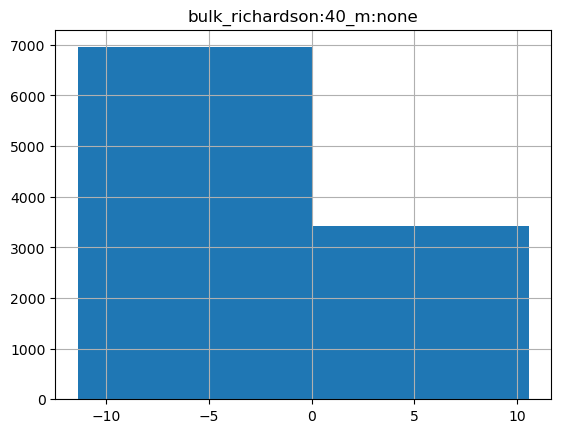

In [17]:
#
# Determine the distribution of stable and unstable cases
#
p = der.hist(column = "bulk_richardson:40_m:none",   bins = [der["bulk_richardson:40_m:none"].min(),0,der["bulk_richardson:40_m:none"].max()])
print("bulkRiMin: ", der["bulk_richardson:40_m:none"].min())
print("bulkRiMax: ",der["bulk_richardson:40_m:none"].max())
print("Unstable cases:" , der["bulk_richardson:40_m:none"].loc[der["bulk_richardson:40_m:none"]< 0].count())
print("Stable cases: ", der["bulk_richardson:40_m:none"].loc[der["bulk_richardson:40_m:none"]> 0].count())

[-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01
  2.00000000e-01  3.00000000e-01  4.00000000e-01  5.00000000e-01
  6.00000000e-01  7.00000000e-01  8.00000000e-01  9.00000000e-01]
Unstable cases: 5069
Stable cases:  2174
Neutral cases:  3132


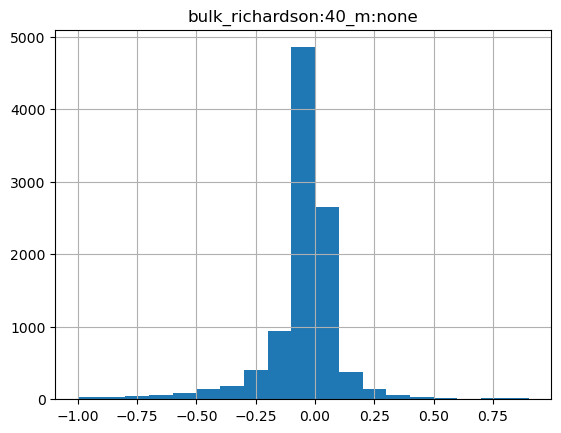

In [20]:
## # Determine the distribution of stable and unstable cases
#
myNumList = np.arange(-1.0,1.0,.1)
print (myNumList)
der.hist(column = "bulk_richardson:40_m:none",   bins = list(myNumList))

print("Unstable cases:" , der["bulk_richardson:40_m:none"].loc[der["bulk_richardson:40_m:none"]< -.02].count())
print("Stable cases: ", der["bulk_richardson:40_m:none"].loc[der["bulk_richardson:40_m:none"]> 0.02].count())
print("Neutral cases: ", der["bulk_richardson:40_m:none"].loc[(der["bulk_richardson:40_m:none"]>= -0.02) & (der["bulk_richardson:40_m:none"]<= 0.02)].count())



Unstable cases: 5069
Stable cases:  2174
Neutral cases:  3132


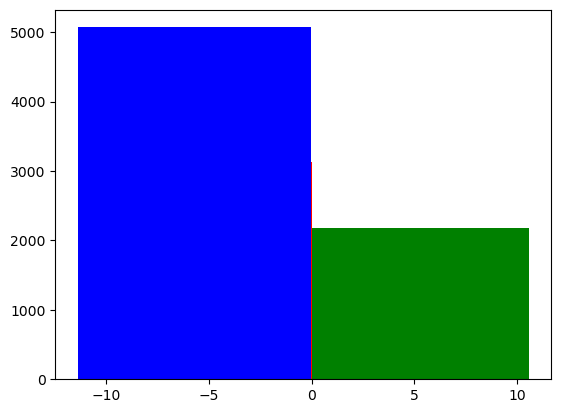

In [21]:
import matplotlib.pyplot as plt
#
# Determine the distribution of stable and unstable cases
#
#der.hist(column = "bulk_richardson:40_m:none",   bins = [der["bulk_richardson:40_m:none"].min(), -.02,.02, der["bulk_richardson:40_m:none"].max()], patches)
#p.patches[1].set_color('r')
print("Unstable cases:" , der["bulk_richardson:40_m:none"].loc[der["bulk_richardson:40_m:none"]< -.02].count())
print("Stable cases: ", der["bulk_richardson:40_m:none"].loc[der["bulk_richardson:40_m:none"]> 0.02].count())
print("Neutral cases: ", der["bulk_richardson:40_m:none"].loc[(der["bulk_richardson:40_m:none"]>= -0.02) & (der["bulk_richardson:40_m:none"]<= 0.02)].count())

# not the best rep of the neutral ;o
n, bins, patches = plt.hist(der["bulk_richardson:40_m:none"], bins = [der["bulk_richardson:40_m:none"].min(), -.02,.02, der["bulk_richardson:40_m:none"].max()])
patches[1].set_fc('r')
patches[0].set_fc('b')
patches[2].set_fc('g')

array([[<Axes: title={'center': 'bulk_richardson:40_m:none'}>]],
      dtype=object)

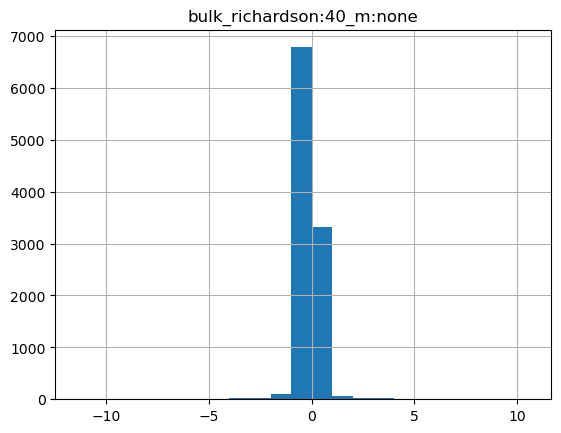

In [22]:
der.hist(column = "bulk_richardson:40_m:none",   bins = [der["bulk_richardson:40_m:none"].min(),-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,der["bulk_richardson:40_m:none"].max()])

In [23]:
print(der.columns)

Index(['Time', 'global_horizontal_irradiance:30_m:W_m-2', 'zenith:0_m:degrees',
       'azimuth:0_m:degrees', 'temperature:40_m:K', 'temperature:50_m:K',
       'temperature:60_m:K', 'temperature:80_m:K',
       'water_sfc_temperature:0_m:K', 'pressure:0_m:hPa', 'pressure:30_m:hPa',
       'pressure:40_m:hPa', 'pressure:50_m:hPa', 'pressure:60_m:hPa',
       'pressure:80_m:hPa', 'potential_temperature:40_m:K',
       'potential_temperature:50_m:K', 'potential_temperature:60_m:K',
       'potential_temperature:80_m:K',
       'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:40_m:g_kg-1', 'mixing_ratio:60_m:g_kg-1',
       'mixing_ratio:80_m:g_kg-1', 'relative_humidity:40_m:%',
       'relative_humidity:60_m:%', 'relative_humidity:80_m:%',
       'wave_dir_linear_interp:0_m:degrees',
       'wave_dir_nearest_interp:0_m:degrees', 'wave_height:0_m:m',
       'wave_period:0_m:s', 'wave_phase_speed:0_m:m_s-1', 'wave_u:0_m:m_s-1',
       'wave_v:0_m:

In [24]:

import pandas as pd
#
# After running train_offshore_models_MVCO.py ../config/offshore_surface_layer_training_2010.yml
# Read in the predictions from the test data
#
pred = pd.read_csv("/glade/campaign/ral/wsap/oracleMLSL/data/models/fino_2010/surface_layer_model_predictions.csv")
pred['Time'] = pd.to_datetime(pred['Time'])
pred.index = pred['Time'] 


In [25]:
print(pred.columns)


Index(['Time', 'momentum_flux-random_forest', 'momentum_flux-neural_network',
       'momentum_flux-mo', 'heat_flux-random_forest',
       'heat_flux-neural_network', 'heat_flux-mo',
       'global_horizontal_irradiance:30_m:W_m-2', 'zenith:0_m:degrees',
       'azimuth:0_m:degrees', 'temperature:40_m:K',
       'water_sfc_temperature:0_m:K', 'wave_dir_linear_interp:0_m:degrees',
       'wave_height:0_m:m', 'wave_period:0_m:s', 'wave_phase_speed:0_m:m_s-1',
       'wave_u:0_m:m_s-1', 'wave_v:0_m:m_s-1', 'wind_speed:40_m:m_s-1',
       'wind_direction:40_m:degrees', 'angle_between_wind_wave:0_m:degrees',
       'relative_humidity:40_m:%', 'pressure:40_m:hPa',
       'potential_temperature:40_m:K',
       'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:40_m:g_kg-1', 'u_wind:40_m:m_s-1', 'v_wind:40_m:m_s-1',
       'MOST_momentum_flux:40_m:m2_s-2', 'MOST_heat_flux:40_m:K_m_s-1',
       'heat_flux:40_m:K_m_s-1', 'momentum_flux:40_m:m2_s-2'],
    

<Axes: xlabel='Time'>

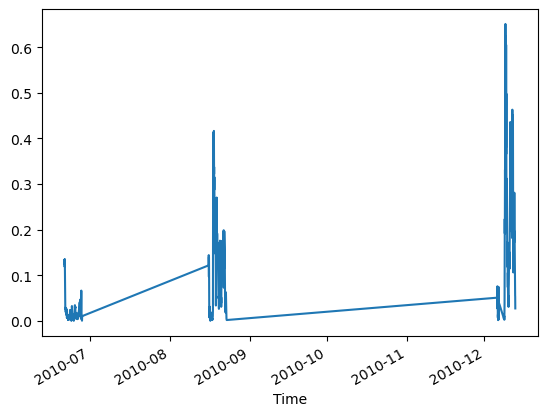

In [26]:
pred['MOST_momentum_flux:40_m:m2_s-2'].plot()

/glade/derecho/scratch/dettling/tmp/ipykernel_5913/3873563462.py:31: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



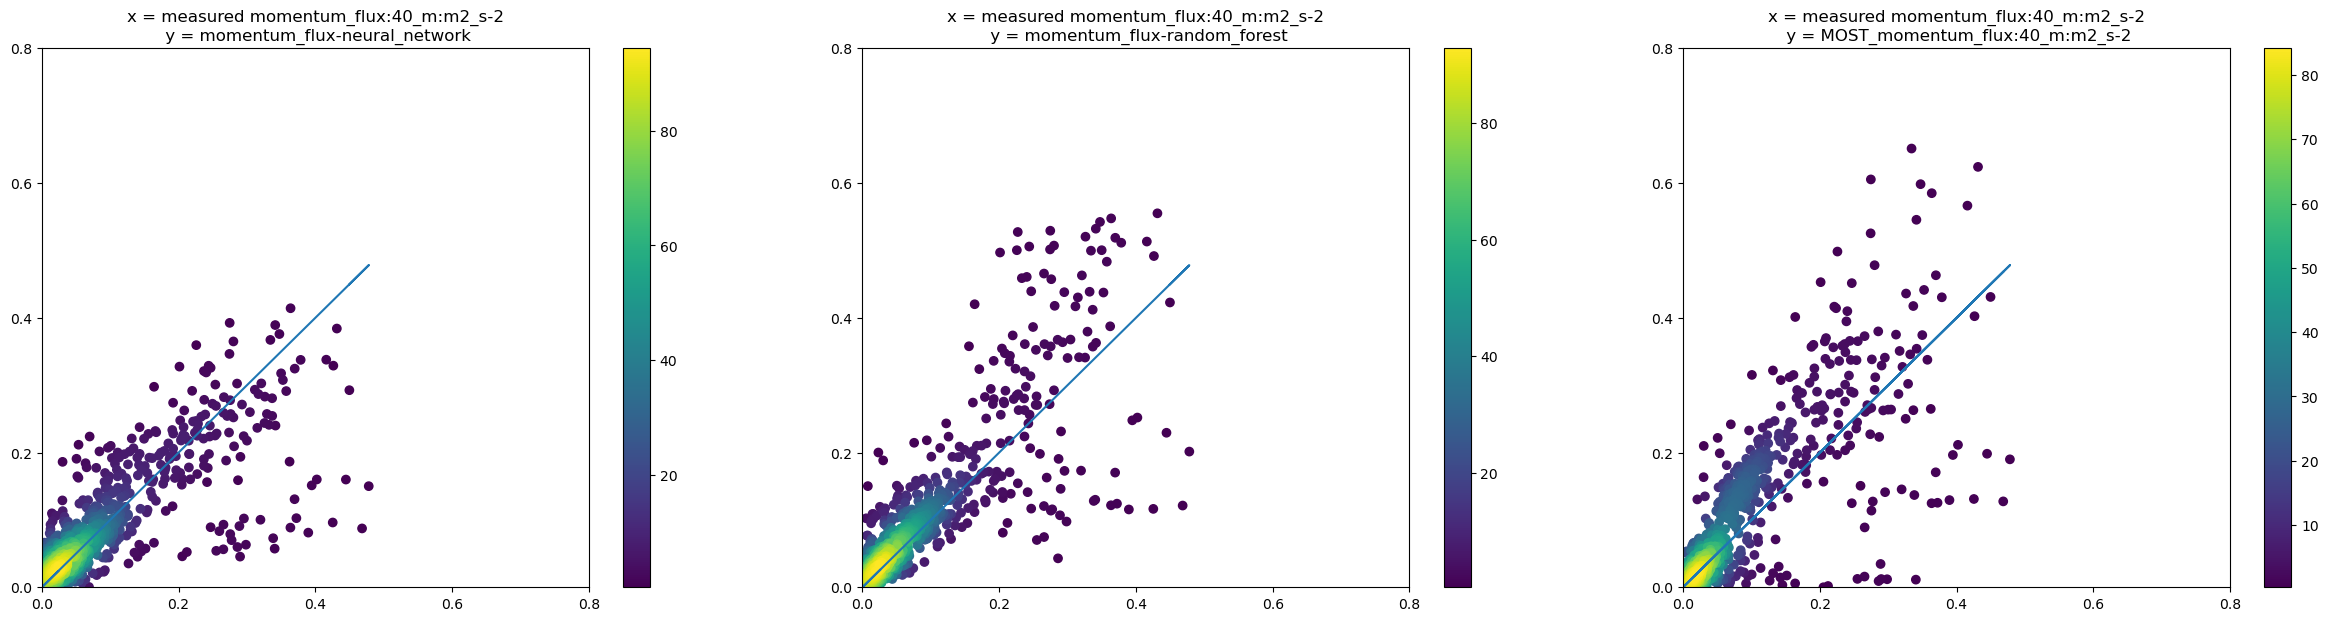

In [55]:
#
# Create some scatter plots for quick visual comparison of ML models and also MOST calcs
#

xStr=  'momentum_flux:40_m:m2_s-2'

yStr = []

yStr.append('momentum_flux-neural_network')
yStr.append('momentum_flux-random_forest')
yStr.append('MOST_momentum_flux:40_m:m2_s-2')

from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize = (30,7))
ax = ax.flat

# Create a shared colormap and normalization

cmap = plt.cm.viridis

for i in range (0,len(ax)):
    x = pred[xStr]
    y = pred[yStr[i]]

    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]


    im = ax[i].scatter(x,y,  c=z , cmap = cmap)
    #ax[i].axis('equal')
    ax[i].set_xlim(0,.8)
    ax[i].set_ylim(0,.8)
    ax[i].set_xticks([0,.2,.4,.6, .8])
    ax[i].set_yticks([0,.2,.4,.6, .8])
    fig.colorbar(im, ax = ax[i])
    titleStr = "x = measured {0}\n y = {1}". format(xStr, yStr[i])
    ax[i].set_title(titleStr )
    ax[i].plot(x, x)


/glade/derecho/scratch/dettling/tmp/ipykernel_5913/1629046111.py:26: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



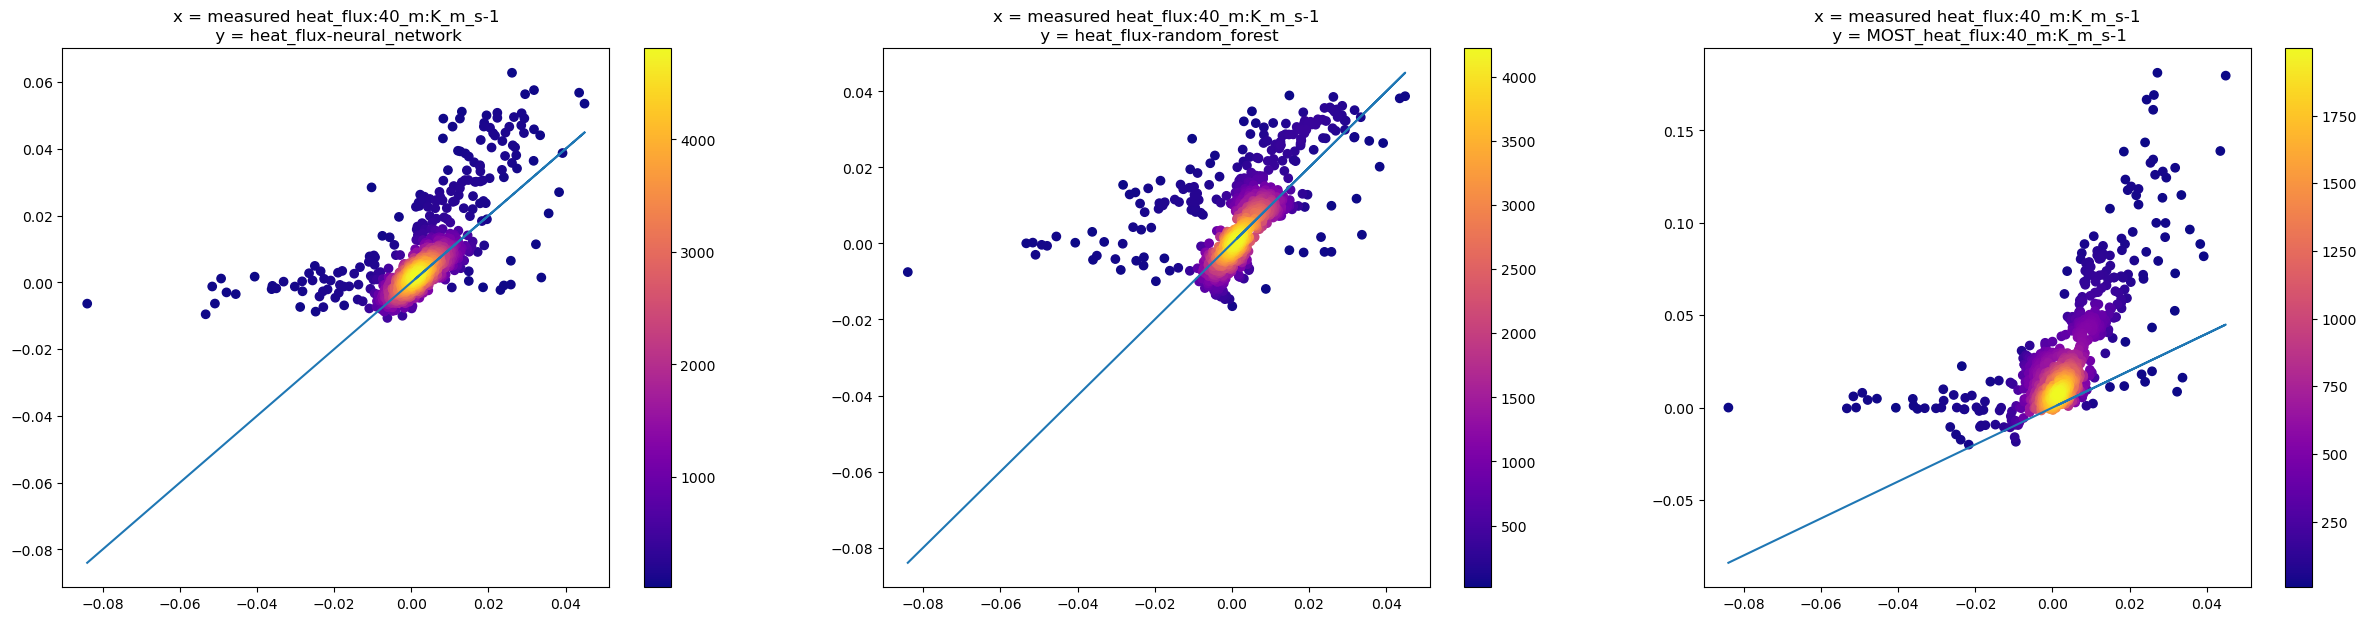

In [48]:
#
# Create some scatter plots for quick visual comparison of ML models and also MOST calcs
#

xStr=  'heat_flux:40_m:K_m_s-1'

yStr = []

yStr.append('heat_flux-neural_network')
yStr.append('heat_flux-random_forest')
yStr.append('MOST_heat_flux:40_m:K_m_s-1')

from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize = (30,7))
ax = ax.flat
for i in range (0,len(ax)):
    x = pred[xStr]
    y = pred[yStr[i]]

    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]


    im = ax[i].scatter(x,y,  c=z, cmap = 'plasma' )
    #ax[i].axis('equal')
    #ax[i].set_xlim(0,.6)
    #ax[i].set_ylim(0,.6)
    #ax[i].set_xticks([0,.2,.4,.6])
    #ax[i].set_yticks([0,.2,.4,.6])
    fig.colorbar(im, ax = ax[i])
    titleStr = "x = measured {0}\n y = {1}". format(xStr, yStr[i])
    ax[i].set_title(titleStr )
    ax[i].plot(x, x)


In [60]:
# Sample display of avg importance of 5 trials
import pandas as pd

impRf = pd.read_csv("/glade/campaign/ral/wsap/oracleMLSL/data/models/fino_2010/momentum_flux_random_forest_importances.csv")
print(impRf.columns)
impRf['aveImp'] = abs(impRf[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impRf[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlot = impRf[['input', 'aveImp']].sort_values(by = 'aveImp')



Index(['input', 'all_0', 'all_1', 'all_2', 'all_3', 'all_4'], dtype='object')
                                       input    aveImp
9        angle_between_wind_wave:0_m:degrees  0.001742
3                water_sfc_temperature:0_m:K  0.002148
1                        azimuth:0_m:degrees  0.002547
13  skin_virtual_potential_temperature:0_m:K  0.003293
0                         zenith:0_m:degrees  0.003400
5                          wave_period:0_m:s  0.003704
14                   mixing_ratio:0_m:g_kg-1  0.003814
6                 wave_phase_speed:0_m:m_s-1  0.003839
10                  relative_humidity:40_m:%  0.003894
11                         pressure:40_m:hPa  0.005424
15                  mixing_ratio:40_m:g_kg-1  0.005861
2                         temperature:40_m:K  0.006522
12              potential_temperature:40_m:K  0.006524
4                          wave_height:0_m:m  0.014242
8                wind_direction:40_m:degrees  0.032312
7                      wind_speed:40_m:m_s

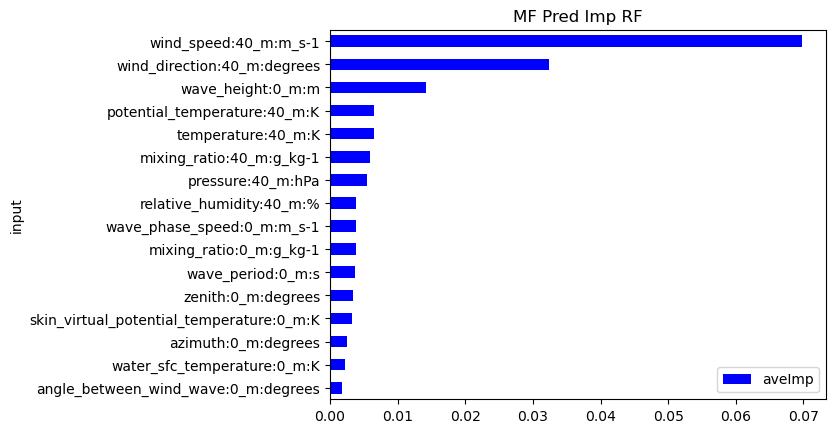

In [72]:
ax = barPlot.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'MF Pred Imp RF')
#ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])
